In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\default+of+credit+card+clients\default of credit card clients.csv")
print(df)

if 'ID' in df.columns:
    df = df.drop('ID', axis=1)


df = df.rename(columns={'default payment next month': 'target'})


cols_with_nans = ['EDUCATION', 'MARRIAGE', 'PAY_0']
for col in cols_with_nans:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4) 
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)           


X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)


print(f"Total missing values remaining: {X_train_final.isna().sum().sum()}")
print(f"Shape of final training data: {X_train_final.shape}")
print("\nPreview of cleaned and scaled data:")
print(X_train_final.head())

            ID      LIMIT_BAL  SEX  EDUCATION  MARRIAGE        AGE  PAY_0  \
0          1.0   20400.820770  2.0        2.0       1.0  24.268819    2.0   
1          2.0  119648.814595  2.0        2.0       2.0  26.726594   -1.0   
2          3.0   82918.523034  2.0        2.0       2.0  34.059775    0.0   
3          4.0   52943.714058  2.0        NaN       1.0  36.493888    0.0   
4          5.0   51625.903002  1.0        2.0       1.0  57.316925   -1.0   
...        ...            ...  ...        ...       ...        ...    ...   
29995  29996.0  214123.220167  1.0        3.0       1.0  39.089335    0.0   
29996  29997.0  149995.075572  1.0        3.0       2.0  42.910003   -1.0   
29997  29998.0   28875.171501  1.0        2.0       2.0  36.647235    4.0   
29998  29999.0   97827.116555  1.0        3.0       1.0  41.040130    1.0   
29999  30000.0   47818.676624  1.0        2.0       1.0  45.567699    0.0   

       PAY_2  PAY_3  PAY_4  ...     BILL_AMT4     BILL_AMT5     BILL_AMT6  

PCA complete. Reduced feature count from 23 to 15.


C:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


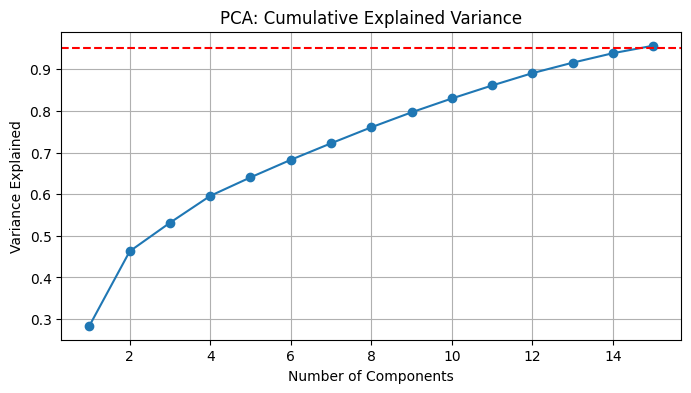

Training K-NN (k=5)...
Training SVM (Linear)...
Training SVM (RBF)...
Training SVM (Polynomial)...


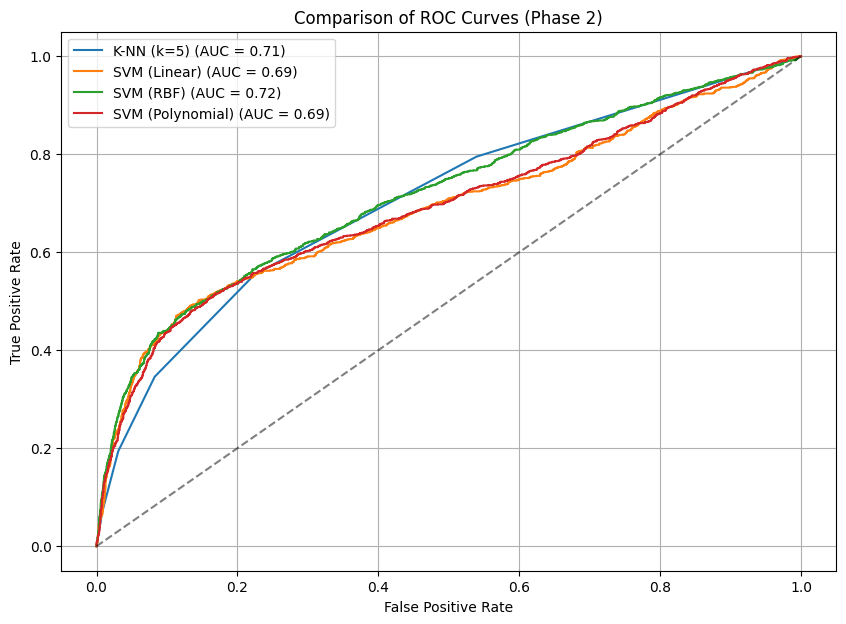


--- FINAL COMPARISON TABLE ---
              Model  Accuracy       AUC  Recall (Default)  \
2         SVM (RBF)  0.812167  0.718159          0.357950   
0        K-NN (k=5)  0.791000  0.707069          0.345893   
3  SVM (Polynomial)  0.804000  0.692385          0.220045   
1      SVM (Linear)  0.807333  0.689804          0.240392   

   Precision (Default)  F1-Score (Default)    Time (s)  
2             0.633333            0.457390  121.721083  
0             0.543195            0.422652    1.593064  
3             0.674365            0.331818  176.976879  
1             0.683084            0.355630  333.951489  


In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score
import time


pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA complete. Reduced feature count from {X_train_final.shape[1]} to {X_train_pca.shape[1]}.")


plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.grid(True)
plt.show()


models = {
    'K-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Polynomial)': SVC(kernel='poly', degree=3, probability=True, random_state=42)
}


results_list = []
plt.figure(figsize=(10, 7)) # For the ROC Curve plot

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
  
    model.fit(X_train_pca, y_train)
    
   
    y_pred = model.predict(X_test_pca)
    y_proba = model.predict_proba(X_test_pca)[:, 1]
    
    elapsed = time.time() - start_time
    
    
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    
    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': auc,
        'Recall (Default)': report['1.0']['recall'],
        'Precision (Default)': report['1.0']['precision'],
        'F1-Score (Default)': report['1.0']['f1-score'],
        'Time (s)': elapsed
    })
    
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves (Phase 2)')
plt.legend()
plt.grid(True)
plt.show()


comparison_df = pd.DataFrame(results_list).sort_values(by='AUC', ascending=False)
print("\n--- FINAL COMPARISON TABLE ---")
print(comparison_df)


In [15]:
import pandas as pd
import numpy as np


def predict_loan_default():
    print("--- Loan Default Prediction System ---")
    print("Please enter the following customer details:")
    
    try:
        # 1. Take inputs sequentially
        print("\n-- Basic Information --")
        limit_bal = float(input("Credit Limit (LIMIT_BAL) [e.g., 50000]: "))
        sex = float(input("Gender (1=Male, 2=Female): "))
        education = float(input("Education (1=Grad, 2=Uni, 3=HS, 4=Other): "))
        marriage = float(input("Marital Status (1=Married, 2=Single, 3=Other): "))
        age = float(input("Age [e.g., 25]: "))
        
        print("\n-- Repayment Status (-1=Pay duly, 1=Delay 1 month, 2=Delay 2 months...) --")
        pay_0 = float(input("Repayment status in September (PAY_0): "))
        pay_2 = float(input("Repayment status in August (PAY_2): "))
        pay_3 = float(input("Repayment status in July (PAY_3): "))
        pay_4 = float(input("Repayment status in June (PAY_4): "))
        pay_5 = float(input("Repayment status in May (PAY_5): "))
        pay_6 = float(input("Repayment status in April (PAY_6): "))
        
        print("\n-- Bill Statements (Amount of bill statement) --")
        bill_amt1 = float(input("Bill statement in September (BILL_AMT1): "))
        bill_amt2 = float(input("Bill statement in August (BILL_AMT2): "))
        bill_amt3 = float(input("Bill statement in July (BILL_AMT3): "))
        bill_amt4 = float(input("Bill statement in June (BILL_AMT4): "))
        bill_amt5 = float(input("Bill statement in May (BILL_AMT5): "))
        bill_amt6 = float(input("Bill statement in April (BILL_AMT6): "))
        
        print("\n-- Previous Payments (Amount of previous payment) --")
        pay_amt1 = float(input("Previous payment in September (PAY_AMT1): "))
        pay_amt2 = float(input("Previous payment in August (PAY_AMT2): "))
        pay_amt3 = float(input("Previous payment in July (PAY_AMT3): "))
        pay_amt4 = float(input("Previous payment in June (PAY_AMT4): "))
        pay_amt5 = float(input("Previous payment in May (PAY_AMT5): "))
        pay_amt6 = float(input("Previous payment in April (PAY_AMT6): "))
        
    except ValueError:
        print("\n[Error] Invalid input! Please enter numerical values only.")
        return

    # 2. Store user input in a list
    user_data = [
        limit_bal, sex, education, marriage, age, 
        pay_0, pay_2, pay_3, pay_4, pay_5, pay_6,
        bill_amt1, bill_amt2, bill_amt3, bill_amt4, bill_amt5, bill_amt6,
        pay_amt1, pay_amt2, pay_amt3, pay_amt4, pay_amt5, pay_amt6
    ]

   
    feature_names = [
        'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
        'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 
        'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 
        'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
    ]
    user_df = pd.DataFrame([user_data], columns=feature_names)

   
    user_df['EDUCATION'] = user_df['EDUCATION'].replace([0, 5, 6], 4)
    user_df['MARRIAGE'] = user_df['MARRIAGE'].replace(0, 3)

   
    user_scaled = scaler.transform(user_df)

    
    user_pca = pca.transform(user_scaled)

    
    best_model = models['SVM (RBF)']
    
    
    prediction = best_model.predict(user_pca)
    probability = best_model.predict_proba(user_pca)[0][1]

   
    print("\n" + "="*45)
    print("             PREDICTION RESULT")
    print("="*45)
    
    if prediction[0] == 1.0:
        print("⚠️  WARNING: The customer is likely to DEFAULT.")
    else:
        print("✅  SAFE: The customer is NOT likely to default.")
        
    print(f"Confidence (Probability of Default): {probability * 100:.2f}%")
    print("="*45)

predict_loan_default()

--- Loan Default Prediction System ---
Please enter the following customer details:

-- Basic Information --


Credit Limit (LIMIT_BAL) [e.g., 50000]:  25000
Gender (1=Male, 2=Female):  1
Education (1=Grad, 2=Uni, 3=HS, 4=Other):  2
Marital Status (1=Married, 2=Single, 3=Other):  2
Age [e.g., 25]:  19



-- Repayment Status (-1=Pay duly, 1=Delay 1 month, 2=Delay 2 months...) --


Repayment status in September (PAY_0):  2000
Repayment status in August (PAY_2):  5000
Repayment status in July (PAY_3):  3000
Repayment status in June (PAY_4):  6000
Repayment status in May (PAY_5):  7000
Repayment status in April (PAY_6):  1000



-- Bill Statements (Amount of bill statement) --


Bill statement in September (BILL_AMT1):  1000
Bill statement in August (BILL_AMT2):  2000
Bill statement in July (BILL_AMT3):  3000
Bill statement in June (BILL_AMT4):  4000
Bill statement in May (BILL_AMT5):  5000
Bill statement in April (BILL_AMT6):  6000



-- Previous Payments (Amount of previous payment) --


Previous payment in September (PAY_AMT1):  1000
Previous payment in August (PAY_AMT2):  2000
Previous payment in July (PAY_AMT3):  3000
Previous payment in June (PAY_AMT4):  4000
Previous payment in May (PAY_AMT5):  5000
Previous payment in April (PAY_AMT6):  6000



             PREDICTION RESULT
✅  SAFE: The customer is NOT likely to default.
Confidence (Probability of Default): 21.11%


C:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
